In [20]:
import os
import numpy as np
import pandas as pd

dataset_dir = '/cluster/tufts/hugheslab/datasets/RSNA'
subject_ids = [filename.split('.')[0] for root, dirs, files in os.walk(f'{dataset_dir}/labels') for filename in files]        
labels = [np.load(f'{root}/{filename}') for root, dirs, files in os.walk(f'{dataset_dir}/labels') for filename in files]        
slice_labels = [list(np.load(f'{root}/{filename}')) for root, dirs, files in os.walk(f'{dataset_dir}/slice_labels') for filename in files]        

labels_df = pd.DataFrame({'ID': subject_ids, 'label': labels, 'slice_label': slice_labels})
#labels_df.to_csv(f'{dataset_dir}/SmAP_labels.csv', index=False)
print(labels_df.shape)
labels_df.head()

(1149, 3)


,ID,label,slice_label
0,ID_00047d6503,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,ID_0004f7a877,1,"[0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,ID_0006600dd8,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,ID_000b852931,1,"[0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, ..."
4,ID_00135fb9ff,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [2]:
import numpy as np

np.round(np.linspace(0, 178, 11)).astype(int)
#[1, 18, 36, 53, 71, 89, 107, 125, 142, 160, 178]

array([  0,  18,  36,  53,  71,  89, 107, 125, 142, 160, 178])

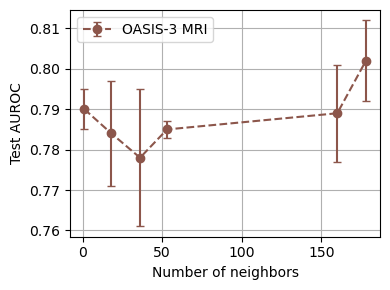

In [1]:
import matplotlib.pyplot as plt

num_neighbors = [1, 18, 36, 53, 160, 178]
auroc_means = [0.790, 0.784, 0.778, 0.785, 0.789, 0.802]
auroc_stds = [0.005, 0.013, 0.017, 0.002, 0.012, 0.010]

ncols, nrows = 1, 1
fig, ax = plt.subplots(figsize=(4*ncols,3*nrows), ncols=ncols, nrows=nrows)

ax.errorbar(num_neighbors, auroc_means, auroc_stds, capsize=3, color='#8C564B', label='OASIS-3 MRI', linestyle="--", marker='o')
ax.set_xlabel('Number of neighbors')
ax.set_ylabel('Test AUROC')
ax.legend()
ax.grid()

fig.tight_layout()
fig.savefig("smap_varying_number_of_neighbors.pdf", bbox_inches="tight")
plt.show()

In [1]:
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 10})
from sklearn.model_selection import train_test_split
# Neuroimaging
import ants

In [2]:
import sys
sys.path.append('../src/')

%load_ext autoreload
%autoreload 2
# Importing our custom module(s)
import ct
import mri

In [3]:
csv_filename = 'ADDF_2024_External_MRimage_800.csv'
dicom_dir = '/cluster/tufts/hugheslabkp/data_irb_required/ADDF_2024_External_MRimage_800'
labels_df = pd.read_csv(f'{dicom_dir}/{csv_filename}')
# See convert_kpsc_mri.py to convert dicom to nifti (.dcm to .nii.gz)
nifti_dir = '/cluster/tufts/hugheslabkp/data_irb_required/KPSC_MRI_800_nifti'
labels_df['paths'] = labels_df['STUDY_ID'].apply(lambda study_id: [f'{nifti_dir}/{study_id}/T1.nii.gz', f'{nifti_dir}/{study_id}/T2.nii.gz'])
print(labels_df.shape)
labels_df.head()

(800, 16)


,STUDY_ID,YearOfScan,SiteID,AgeOfScan,Sex,RaceETH,idWMD,idWMD_Severity,idCBI,idCBI_Location,Stroke,daysfu_str,Dementia,daysfu_dem,withDiffusion,paths
0,STUDY_0010,2009,3,58,M,Asian and Pacific Islander,1,Mild,0,No,0,344,0,344,0,[/cluster/tufts/hugheslabkp/data_irb_required/...
1,STUDY_0016,2014,11,56,F,White,0,No,0,No,0,1954,0,1954,0,[/cluster/tufts/hugheslabkp/data_irb_required/...
2,STUDY_0018,2016,3,64,F,Hispanic,1,Mild,0,No,0,1390,0,1390,0,[/cluster/tufts/hugheslabkp/data_irb_required/...
3,STUDY_0019,2017,3,82,M,Black,1,Moderate,1,Sub-cortical,1,437,0,918,1,[/cluster/tufts/hugheslabkp/data_irb_required/...
4,STUDY_0020,2017,3,53,M,White,1,Mild,0,No,0,803,0,803,0,[/cluster/tufts/hugheslabkp/data_irb_required/...


(256, 256, 22)


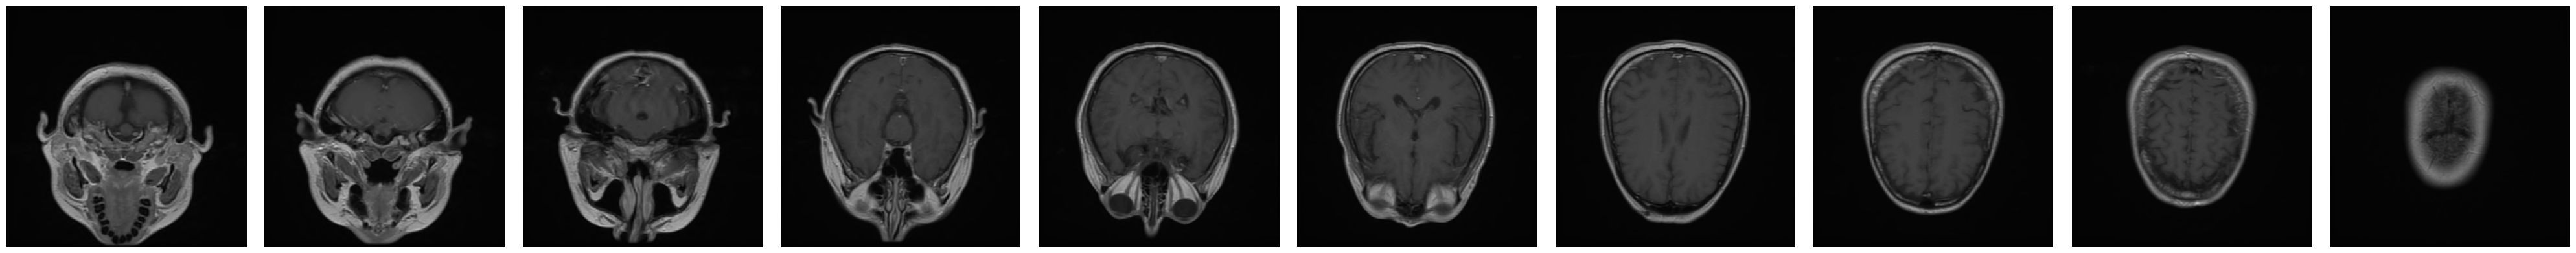

In [4]:
image = ants.image_read(labels_df.iloc[0].paths[0]).numpy()
print(image.shape)
linspace = np.linspace(0, image.shape[-1] - 1, 10).astype(int)

ncols, nrows = 10, 1
fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(4*ncols,4*nrows))

for i, j in enumerate(linspace):
    axs[i].imshow(np.rot90(image[:,:,j], k=1, axes=(-2, -1)), cmap='gray', vmin=np.min(image), vmax=np.max(image))
    axs[i].set_axis_off()
    
fig.tight_layout()
plt.show()

In [5]:
csv_filename = 'ADDF_2024_External_MRimage_800.csv'
dicom_dir = '/cluster/tufts/hugheslabkp/data_irb_required/ADDF_2024_External_MRimage_800'
labels_df = pd.read_csv(f'{dicom_dir}/{csv_filename}')
# See preprocess_kpsc_mri.py to convert nifti to numpy (.nii.gz to .npz)
numpy_dir = '/cluster/tufts/hugheslabkp/data_irb_required/KPSC_MRI_800_numpy'
labels_df['path'] = labels_df['STUDY_ID'].apply(lambda study_id: f'{numpy_dir}/{study_id}.npz')
labels_df.to_csv(f'{numpy_dir}/labels.csv')
print(labels_df.shape)
labels_df.head()

(800, 16)


,STUDY_ID,YearOfScan,SiteID,AgeOfScan,Sex,RaceETH,idWMD,idWMD_Severity,idCBI,idCBI_Location,Stroke,daysfu_str,Dementia,daysfu_dem,withDiffusion,path
0,STUDY_0010,2009,3,58,M,Asian and Pacific Islander,1,Mild,0,No,0,344,0,344,0,/cluster/tufts/hugheslabkp/data_irb_required/K...
1,STUDY_0016,2014,11,56,F,White,0,No,0,No,0,1954,0,1954,0,/cluster/tufts/hugheslabkp/data_irb_required/K...
2,STUDY_0018,2016,3,64,F,Hispanic,1,Mild,0,No,0,1390,0,1390,0,/cluster/tufts/hugheslabkp/data_irb_required/K...
3,STUDY_0019,2017,3,82,M,Black,1,Moderate,1,Sub-cortical,1,437,0,918,1,/cluster/tufts/hugheslabkp/data_irb_required/K...
4,STUDY_0020,2017,3,53,M,White,1,Mild,0,No,0,803,0,803,0,/cluster/tufts/hugheslabkp/data_irb_required/K...


In [6]:
starts = np.linspace(0, 800, num=11).astype(int)[:-1]
stops = np.linspace(0, 800, num=11).astype(int)[1:]
for start, stop in zip(starts, stops):
    print(f'    \"python ../src/preprocess_kpsc_mri.py --csv_filename=\'{csv_filename}\' --dicom_dir=\'{dicom_dir}\' --nifti_dir=\'{nifti_dir}\' --numpy_dir=\'{numpy_dir}\' --start={start} --stop={stop}\"')

    "python ../src/preprocess_kpsc_mri.py --csv_filename='ADDF_2024_External_MRimage_800.csv' --dicom_dir='/cluster/tufts/hugheslabkp/data_irb_required/ADDF_2024_External_MRimage_800' --nifti_dir='/cluster/tufts/hugheslabkp/data_irb_required/KPSC_MRI_800_nifti' --numpy_dir='/cluster/tufts/hugheslabkp/data_irb_required/KPSC_MRI_800_numpy' --start=0 --stop=80"
    "python ../src/preprocess_kpsc_mri.py --csv_filename='ADDF_2024_External_MRimage_800.csv' --dicom_dir='/cluster/tufts/hugheslabkp/data_irb_required/ADDF_2024_External_MRimage_800' --nifti_dir='/cluster/tufts/hugheslabkp/data_irb_required/KPSC_MRI_800_nifti' --numpy_dir='/cluster/tufts/hugheslabkp/data_irb_required/KPSC_MRI_800_numpy' --start=80 --stop=160"
    "python ../src/preprocess_kpsc_mri.py --csv_filename='ADDF_2024_External_MRimage_800.csv' --dicom_dir='/cluster/tufts/hugheslabkp/data_irb_required/ADDF_2024_External_MRimage_800' --nifti_dir='/cluster/tufts/hugheslabkp/data_irb_required/KPSC_MRI_800_nifti' --numpy_dir='/

(169, 208, 179)


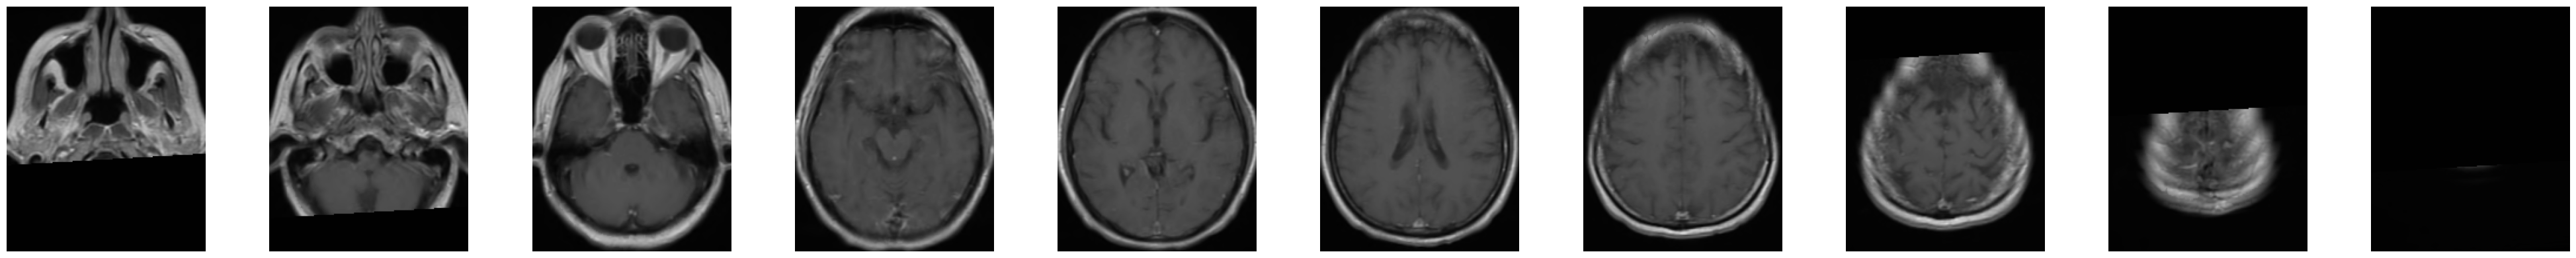

In [7]:
image = np.load(labels_df.iloc[0].path)['arr_0'][0]
print(image.shape)
linspace = np.linspace(0, image.shape[-1] - 1, 10).astype(int)

ncols, nrows = 10, 1
fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(4*ncols,4*nrows))

for i, j in enumerate(linspace):
    axs[i].imshow(np.rot90(image[:,:,j], k=1, axes=(-2, -1)), cmap='gray', vmin=np.min(image), vmax=np.max(image))
    axs[i].set_axis_off()
    
fig.tight_layout()
plt.show()

In [5]:
################################################################################
def print_job(
    alpha, batch_size, criterion, dataset_dir, epochs, embedding_level, 
    experiments_dir, lr, pooling, save, seed, weight_decay
):
    
    model_name = f'alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}'
    
    if os.path.exists(f'{experiments_dir}/{model_name}.csv'):
        temp_df = pd.read_csv(f'{experiments_dir}/{model_name}.csv')
        if temp_df.shape[0] == epochs:
            return
        
    embedding_level = '--embedding_level ' if embedding_level else ''
    save = '--save ' if save else ''
    
    command = (
        f'python ../src/kpsc.py '
        f'--alpha={alpha} '
        f'--batch_size={batch_size} '
        f'--criterion=\'{criterion}\' '
        f'--dataset_dir=\'{dataset_dir}\' '
        f'--epochs={epochs} '
        f'{embedding_level}'
        f'--experiments_dir=\'{experiments_dir}\' '
        f'--lr={lr} '
        f'--model_name=\'{model_name}\' '
        f'--pooling=\'{pooling}\' '
        f'{save}'
        f'--seed={seed} '
        f'--weight_decay={weight_decay}'
    )
    
    print(f'    \"{command}\"')
    
    
    
################################################################################
#"""
def print_job(
    alpha, args_split, batch_size, criterion, dataset_dir, epochs, embedding_level, 
    experiments_dir, lr, pooling, save, seed, weight_decay
):
    
    model_name = f'alpha={alpha}_criterion={criterion}_lr={lr}_seed={seed}'
    
    if os.path.exists(f'{experiments_dir}/{model_name}.csv'):
        temp_df = pd.read_csv(f'{experiments_dir}/{model_name}.csv')
        if temp_df.shape[0] == epochs:
            return
        
    embedding_level = '--embedding_level ' if embedding_level else ''
    save = '--save ' if save else ''
    
    command = (
        f'python ../src/fine-tune_oasis-3-Copy3.py '
        f'--alpha={alpha} '
        f'--batch_size={batch_size} '
        f'--criterion=\'{criterion}\' '
        f'--dataset_dir=\'{dataset_dir}\' '
        f'--epochs={epochs} '
        f'{embedding_level}'
        f'--experiments_dir=\'{experiments_dir}\' '
        f'--lr={lr} '
        f'--model=\'OnTheDesign\' '
        f'--model_name=\'{model_name}\' '
        f'{save}'
        f'--seed={seed} '
        f'{args_split} '
        f'--weight_decay={weight_decay}'
    )
    
    print(f'    \"{command}\"')    
#"""

In [6]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
args_splits = ['--test_site_ids 9 --train_site_ids 1 2 3 4 6 7 8 10 11 --val_site_ids 5',
               '--test_site_ids 1 4 7 10 11 --train_site_ids 2 3 5 6 8 --val_site_ids 9',
               '--test_site_ids 2 6 --train_site_ids 3 5 8 9 --val_site_ids 1 4 7 10 11',
               '--test_site_ids 3 8 --train_site_ids 1 4 5 7 9 10 11 --val_site_ids 2 6',
               '--test_site_ids 5 --train_site_ids 1 2 4 6 7 9 10 11 --val_site_ids 3 8']
beta = 0.0
batch_size = 4
criterions = ['L2']
#dataset_dir = '/cluster/tufts/hugheslabkp/data_irb_required/encoded_KPSC_MRI_800/ViT_B_16' 
dataset_dir = '/cluster/tufts/hugheslabkp/data_irb_required/KPSC_MRI_800_numpy' 
epochs = 100
embedding_level = False
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_WMD_embedding_level=False' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_CBI_embedding_level=False' 
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_CBI_3D_ResNet-18' 
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_CBI_OnTheDesign' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_WMD_3D_ResNet-18' 
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_WMD_OnTheDesign' 
lrs = [0.1, 0.01, 0.001, 0.0001]
poolings = ['Max', 'Mean', 'ABMIL']
poolings = ['Mean']
save = True
seeds = [1001]
splits = ['test_site_ids=9_train_site_ids=1_2_3_4_6_7_8_10_11_val_site_ids=5',
          'test_site_ids=1_4_7_10_11_train_site_ids=2_3_5_6_8_val_site_ids=9',
          'test_site_ids=2_6_train_site_ids=3_5_8_9_val_site_ids=1_4_7_10_11',
          'test_site_ids=3_8_train_site_ids=1_4_5_7_9_10_11_val_site_ids=2_6',
          'test_site_ids=5_train_site_ids=1_2_4_6_7_9_10_11_val_site_ids=3_8']
weight_decay = 0.0

for alpha, criterion, lr, pooling, seed, (args_split, split) in itertools.product(alphas, criterions, lrs, poolings, seeds, zip(args_splits, splits)):
    
    #temp_dataset_dir = f'{dataset_dir}/{split}'
    temp_experiments_dir = f'{experiments_dir}/{split}'

    print_job(alpha, args_split, batch_size, criterion, dataset_dir, epochs, embedding_level, 
              temp_experiments_dir, lr, pooling, save, seed, weight_decay)
    

    "python ../src/fine-tune_oasis-3-Copy3.py --alpha=1.0 --batch_size=4 --criterion='L2' --dataset_dir='/cluster/tufts/hugheslabkp/data_irb_required/KPSC_MRI_800_numpy' --epochs=100 --experiments_dir='/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_WMD_OnTheDesign/test_site_ids=9_train_site_ids=1_2_3_4_6_7_8_10_11_val_site_ids=5' --lr=0.1 --model='OnTheDesign' --model_name='alpha=1.0_criterion=L2_lr=0.1_seed=1001' --save --seed=1001 --test_site_ids 9 --train_site_ids 1 2 3 4 6 7 8 10 11 --val_site_ids 5 --weight_decay=0.0"
    "python ../src/fine-tune_oasis-3-Copy3.py --alpha=1.0 --batch_size=4 --criterion='L2' --dataset_dir='/cluster/tufts/hugheslabkp/data_irb_required/KPSC_MRI_800_numpy' --epochs=100 --experiments_dir='/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_WMD_OnTheDesign/test_site_ids=1_4_7_10_11_train_site_ids=2_3_5_6_8_val_site_ids=9' --lr=0.1 --model='OnTheDesign' --model_name='alpha=1.0_criterion=L2_lr=0.1_seed=1001' --save --seed

In [4]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
beta = 0.0
batch_size = 64
criterions = ['L2']
dataset_dir = '/cluster/tufts/hugheslabkp/data_irb_required/encoded_KPSC_MRI_800/ViT_B_16' 
epochs = 1000
embedding_level = False
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_CBI_embedding_level=False' 
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_WMD_embedding_level=False' 
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_CBI_3D_ResNet-18' 
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_CBI_OnTheDesign' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_WMD_3D_ResNet-18' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_WMD_OnTheDesign' 
lrs = [0.1, 0.01, 0.001, 0.0001]
poolings = ['SmAP']
save = True
seeds = [1001]
splits = ['test_site_ids=9_train_site_ids=1_2_3_4_6_7_8_10_11_val_site_ids=5',
          'test_site_ids=1_4_7_10_11_train_site_ids=2_3_5_6_8_val_site_ids=9',
          'test_site_ids=2_6_train_site_ids=3_5_8_9_val_site_ids=1_4_7_10_11',
          'test_site_ids=3_8_train_site_ids=1_4_5_7_9_10_11_val_site_ids=2_6',
          'test_site_ids=5_train_site_ids=1_2_4_6_7_9_10_11_val_site_ids=3_8']
weight_decay = 0.0

columns = ['model_name', 'split', 'test_auroc', 'test_auprc', 'test_bal_acc', 'test_loss', 'test_nll', 'train_auroc', 'train_auprc', 'train_bal_acc', 'train_loss', 'train_nll', 'val_auroc', 'val_auprc', 'val_bal_acc', 'val_loss', 'val_nll']
df = pd.DataFrame(columns=columns)

for alpha, criterion, lr, pooling, seed, split in itertools.product(alphas, criterions, lrs, poolings, seeds, splits):
    
    model_name = f'alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}'
    model_name = f'alpha={alpha}_criterion={criterion}_lr={lr}_seed={seed}'
    
    if os.path.exists(f'{experiments_dir}/{split}/{model_name}.csv'):
        temp_df = pd.read_csv(f'{experiments_dir}/{split}/{model_name}.csv')
        if len(temp_df[temp_df.train_auroc > temp_df.val_auroc]):
            index = temp_df[temp_df.train_auroc > temp_df.val_auroc].val_auroc.idxmax()
            row = [model_name, split, temp_df.test_auroc.values[index], temp_df.test_auprc.values[index], temp_df.test_bal_acc.values[index], temp_df.test_loss.values[index], temp_df.test_nll.values[index], temp_df.train_auroc.values[index], temp_df.train_auprc.values[index], temp_df.train_bal_acc.values[index], temp_df.train_loss.values[index], temp_df.train_nll.values[index], temp_df.val_auroc.values[index], temp_df.val_auprc.values[index], temp_df.val_bal_acc.values[index], temp_df.val_loss.values[index], temp_df.val_nll.values[index]]
            df.loc[len(df)] = row
        
indices = df.groupby(['split'])['val_auroc'].idxmax()
df = df.loc[indices].reset_index(drop=True)

df.head()

,model_name,split,test_auroc,test_auprc,test_bal_acc,test_loss,test_nll,train_auroc,train_auprc,train_bal_acc,train_loss,train_nll,val_auroc,val_auprc,val_bal_acc,val_loss,val_nll
0,alpha=0.1_criterion=L2_lr=0.001_seed=1001,test_site_ids=1_4_7_10_11_train_site_ids=2_3_5...,0.673344,0.369275,0.589240,1.016062,1.012004,1.000000,1.000000,1.000000,0.004976,0.000938,0.704249,0.498533,0.617932,0.977385,0.973327
1,alpha=0.001_criterion=L2_lr=0.001_seed=1001,test_site_ids=2_6_train_site_ids=3_5_8_9_val_s...,0.679171,0.515095,0.552538,1.137488,0.856883,1.000000,1.000000,0.997076,0.294451,0.013697,0.715460,0.397696,0.536980,1.010114,0.729509
2,alpha=1.0_criterion=L2_lr=0.001_seed=1001,test_site_ids=3_8_train_site_ids=1_4_5_7_9_10_...,0.784502,0.648941,0.703337,0.575528,0.535570,0.997828,0.995584,0.962542,0.116452,0.073993,0.706607,0.547683,0.660041,0.652315,0.612357
3,alpha=0.1_criterion=L2_lr=0.001_seed=1001,test_site_ids=5_train_site_ids=1_2_4_6_7_9_10_...,0.658722,0.657199,0.582108,1.531383,1.502545,1.000000,1.000000,1.000000,0.033889,0.002462,0.782994,0.664811,0.618024,0.720000,0.691161
4,alpha=1e-05_criterion=L2_lr=0.0001_seed=1001,test_site_ids=9_train_site_ids=1_2_3_4_6_7_8_1...,0.650887,0.407277,0.500000,0.602277,0.599459,0.784086,0.592305,0.516237,0.519786,0.516968,0.707940,0.689901,0.500000,0.708147,0.705329


In [4]:
print(f"{df.test_auroc.mean():.3f} +/- {df.test_auroc.std():.3f}")
print(f"{df.test_auprc.mean():.3f} +/- {df.test_auprc.std():.3f}")

0.708 +/- 0.077
0.817 +/- 0.114


In [7]:
# AUROC

# CBI
# Max: 0.553 +/- 0.063
# Mean: 0.620 +/- 0.034
# ABMIL: 0.599 +/- 0.038
# SmAP: 0.597 +/- 0.038

# WMD
# Max: 0.642 +/- 0.059
# Mean: 0.627 +/- 0.070
# ABMIL: 0.664 +/- 0.066
# SmAP: 0.675 +/- 0.055

In [ ]:
# AUPRC

# CBI
# Max: 0.392 +/- 0.103
# Mean: 0.418 +/- 0.108
# ABMIL: 0.406 +/- 0.104
# SmAP: 0.413 +/- 0.093

# WMD
# Max: 0.784 +/- 0.102
# Mean: 0.761 +/- 0.112
# ABMIL: 0.791 +/- 0.095
# SmAP: 0.801 +/- 0.090

In [5]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
beta = 0.0
batch_size = 64
criterions = ['L1']
dataset_dir = '/cluster/tufts/hugheslabkp/data_irb_required/encoded_KPSC_MRI_800/ViT_B_16' 
epochs = 1000
embedding_level = True
embedding_level = False
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_CBI_embedding_level=True' 
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_CBI_embedding_level=False' 
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_WMD_embedding_level=True' 
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_WMD_embedding_level=False' 
lrs = [0.1, 0.01, 0.001, 0.0001]
poolings = ['Max', 'Mean', 'ABMIL', 'TransMIL']
poolings = ['SmAP']
save = True
seeds = [1001]
splits = ['test_site_ids=9_train_site_ids=1_2_3_4_6_7_8_10_11_val_site_ids=5',
          'test_site_ids=1_4_7_10_11_train_site_ids=2_3_5_6_8_val_site_ids=9',
          'test_site_ids=2_6_train_site_ids=3_5_8_9_val_site_ids=1_4_7_10_11',
          'test_site_ids=3_8_train_site_ids=1_4_5_7_9_10_11_val_site_ids=2_6',
          'test_site_ids=5_train_site_ids=1_2_4_6_7_9_10_11_val_site_ids=3_8']
weight_decay = 0.0

for alpha, criterion, lr, pooling, seed, split in itertools.product(alphas, criterions, lrs, poolings, seeds, splits):
    
    temp_dataset_dir = f'{dataset_dir}/{split}'
    temp_experiments_dir = f'{experiments_dir}/{split}'

    print_job(alpha, batch_size, criterion, temp_dataset_dir, epochs, embedding_level, 
              temp_experiments_dir, lr, pooling, save, seed, weight_decay)
    

    "python ../src/kpsc.py --alpha=1.0 --batch_size=64 --criterion='L1' --dataset_dir='/cluster/tufts/hugheslabkp/data_irb_required/encoded_KPSC_MRI_800/ViT_B_16/test_site_ids=9_train_site_ids=1_2_3_4_6_7_8_10_11_val_site_ids=5' --epochs=1000 --experiments_dir='/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_WMD_embedding_level=False/test_site_ids=9_train_site_ids=1_2_3_4_6_7_8_10_11_val_site_ids=5' --lr=0.1 --model_name='alpha=1.0_criterion=L1_lr=0.1_pooling=SmAP_seed=1001' --pooling='SmAP' --save --seed=1001 --weight_decay=0.0"
    "python ../src/kpsc.py --alpha=1.0 --batch_size=64 --criterion='L1' --dataset_dir='/cluster/tufts/hugheslabkp/data_irb_required/encoded_KPSC_MRI_800/ViT_B_16/test_site_ids=1_4_7_10_11_train_site_ids=2_3_5_6_8_val_site_ids=9' --epochs=1000 --experiments_dir='/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_WMD_embedding_level=False/test_site_ids=1_4_7_10_11_train_site_ids=2_3_5_6_8_val_site_ids=9' --lr=0.1 --model_name='

In [5]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
beta = 0.0
batch_size = 64
criterions = ['L1']
dataset_dir = '/cluster/tufts/hugheslabkp/data_irb_required/encoded_KPSC_MRI_800/ViT_B_16' 
epochs = 1000
embedding_level = True
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_CBI_embedding_level=False' 
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_CBI_embedding_level=True' 
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_WMD_embedding_level=False' 
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/KPSC_MRI_800_WMD_embedding_level=True' 
lrs = [0.1, 0.01, 0.001, 0.0001]
poolings = ['SmAP']
save = True
seeds = [1001]
splits = ['test_site_ids=9_train_site_ids=1_2_3_4_6_7_8_10_11_val_site_ids=5',
          'test_site_ids=1_4_7_10_11_train_site_ids=2_3_5_6_8_val_site_ids=9',
          'test_site_ids=2_6_train_site_ids=3_5_8_9_val_site_ids=1_4_7_10_11',
          'test_site_ids=3_8_train_site_ids=1_4_5_7_9_10_11_val_site_ids=2_6',
          'test_site_ids=5_train_site_ids=1_2_4_6_7_9_10_11_val_site_ids=3_8']
weight_decay = 0.0

columns = ['model_name', 'split', 'test_auroc', 'test_auprc', 'test_bal_acc', 'test_loss', 'test_nll', 'train_auroc', 'train_auprc', 'train_bal_acc', 'train_loss', 'train_nll', 'val_auroc', 'val_auprc', 'val_bal_acc', 'val_loss', 'val_nll']
df = pd.DataFrame(columns=columns)

for alpha, criterion, lr, pooling, seed, split in itertools.product(alphas, criterions, lrs, poolings, seeds, splits):
    
    model_name = f'alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}'
    
    if os.path.exists(f'{experiments_dir}/{split}/{model_name}.csv'):
        temp_df = pd.read_csv(f'{experiments_dir}/{split}/{model_name}.csv')
        if len(temp_df[temp_df.train_auroc > temp_df.val_auroc]):
            index = temp_df[temp_df.train_auroc > temp_df.val_auroc].val_auroc.idxmax()
            row = [model_name, split, temp_df.test_auroc.values[index], temp_df.test_auprc.values[index], temp_df.test_bal_acc.values[index], temp_df.test_loss.values[index], temp_df.test_nll.values[index], temp_df.train_auroc.values[index], temp_df.train_auprc.values[index], temp_df.train_bal_acc.values[index], temp_df.train_loss.values[index], temp_df.train_nll.values[index], temp_df.val_auroc.values[index], temp_df.val_auprc.values[index], temp_df.val_bal_acc.values[index], temp_df.val_loss.values[index], temp_df.val_nll.values[index]]
            df.loc[len(df)] = row
        
indices = df.groupby(['split'])['val_auroc'].idxmax()
df = df.loc[indices].reset_index(drop=True)

df.head()

,model_name,split,test_auroc,test_auprc,test_bal_acc,test_loss,test_nll,train_auroc,train_auprc,train_bal_acc,train_loss,train_nll,val_auroc,val_auprc,val_bal_acc,val_loss,val_nll
0,alpha=0.0001_criterion=L1_lr=0.1_pooling=SmAP_...,test_site_ids=1_4_7_10_11_train_site_ids=2_3_5...,0.639368,0.716680,0.496318,1.278432,1.158460,0.834099,0.926743,0.705402,0.565018,0.444427,0.739657,0.837819,0.509615,0.913154,0.793182
1,alpha=0.01_criterion=L1_lr=0.1_pooling=SmAP_se...,test_site_ids=2_6_train_site_ids=3_5_8_9_val_s...,0.680735,0.747617,0.500000,1.366399,0.895556,0.693252,0.864445,0.577542,1.010090,0.551703,0.659842,0.692455,0.515625,1.356710,0.885867
2,alpha=0.01_criterion=L1_lr=0.01_pooling=SmAP_s...,test_site_ids=3_8_train_site_ids=1_4_5_7_9_10_...,0.654987,0.816182,0.549384,0.732385,0.594915,0.820237,0.910796,0.628856,0.611177,0.473556,0.716817,0.795806,0.565641,0.752843,0.615373
3,alpha=0.01_criterion=L1_lr=0.001_pooling=SmAP_...,test_site_ids=5_train_site_ids=1_2_4_6_7_9_10_...,0.828030,0.955401,0.676515,1.047461,0.924791,0.829211,0.897261,0.691895,0.611465,0.489190,0.700039,0.849641,0.621871,1.125562,1.002892
4,alpha=0.001_criterion=L1_lr=0.1_pooling=SmAP_s...,test_site_ids=9_train_site_ids=1_2_3_4_6_7_8_1...,0.658694,0.810372,0.584195,1.284562,1.111675,0.945982,0.967941,0.827976,0.467541,0.293446,0.806313,0.949074,0.599242,0.634109,0.461222


In [6]:
print(f"{df.test_auroc.mean():.3f} +/- {df.test_auroc.std():.3f}")
print(f"{df.test_auprc.mean():.3f} +/- {df.test_auprc.std():.3f}")

0.692 +/- 0.077
0.809 +/- 0.092


In [17]:
# AUROC

# CBI
# Max: 0.648 +/- 0.020
# Mean: 0.610 +/- 0.050
# ABMIL: 0.609 +/- 0.038
# TransMIL: 0.565 +/- 0.060
# SmAP: 0.635 +/- 0.022

# WMD
# Max: 0.644 +/- 0.052
# Mean: 0.640 +/- 0.053
# ABMIL: 0.648 +/- 0.020
# TransMIL: 0.681 +/- 0.054
# SmAP: 0.698 +/- 0.090

In [ ]:
# AUPRC

# CBI
# Max: 0.452 +/- 0.111
# Mean: 0.413 +/- 0.108
# ABMIL: 0.412 +/- 0.113
# TransMIL: 0.392 +/- 0.122
# SmAP: 0.442 +/- 0.089

# WMD
# Max: 0.769 +/- 0.114
# Mean: 0.776 +/- 0.097
# ABMIL: 0.787 +/- 0.070
# TransMIL: 0.807 +/- 0.090
# SmAP: 0.817 +/- 0.092